In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

import matplotlib.pyplot as plt
import time
import datetime

from tqdm import tqdm

In [2]:
class Diffusion:
  def __init__(self, device, img_size=64, channels=3, steps=1000, beta_min=0.001, beta_max=0.02):
    self.device = device
    self.img_size = img_size
    self.channels = channels
    self.steps = steps
    self.beta_min = beta_min
    self.beta_max = beta_max
    self.emb_dim = 256

    self.betas = torch.linspace(beta_min, beta_max, steps, device=device)
    self.alfas = 1.0 - self.betas
    self.alfa_hats = torch.cumprod(self.alfas, 0)

  def get_time(self, n):
    return torch.randint(1, self.steps + 1, (n,), device=self.device)

  def add_noise(self, x, t):
    noise = torch.randn_like(x, device=self.device)

    return torch.sqrt(self.alfa_hats[t - 1])[:, None, None, None] * x +\
    torch.sqrt(1.0 - self.alfa_hats[t - 1])[:, None, None, None] * noise, noise

  def sample(self, model, n=16):
    model.eval()
    with torch.no_grad():
      x = torch.randn((n, self.channels, self.img_size, self.img_size), device=self.device)

      for t in range(self.steps, 0, -1):
        z = torch.zeros_like(x, device=self.device) if t == 1 else torch.randn_like(x, device=self.device)
        predicted_noise = model(x, t * torch.ones((n, ), device=self.device))

        p = 1.0 / torch.sqrt(self.alfas[t - 1])
        q = (1 - self.alfas[t - 1]) / torch.sqrt(1.0 - self.alfa_hats[t - 1])

        x = p * (x - q * predicted_noise) + torch.sqrt(self.betas[t - 1]) * z

      x = 0.5 * (1.0 + x)
      x = x.clamp(0.0, 1.0)
      x = (255.0 * x).long()

      return x

In [3]:
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(DoubleConv, self).__init__()
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.dc = nn.Sequential(
        nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(out_channels),
        nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(out_channels),
    )

  def forward(self, x):
    return self.dc(x)

In [4]:
def get_time_embeding(t, emb_dim=256):
    factor = 1.0 / 10000.0 ** (torch.arange(0, emb_dim, 2, device=t.device, dtype=torch.float) / emb_dim)
    factor = factor.repeat(t.shape[0], 1)

    return torch.cat([torch.sin(t[:, None] * factor), torch.cos(t[:, None] * factor)], dim=1)

class Down(nn.Module):
  def __init__(self, channels, emb_size):
    super(Down, self).__init__()
    self.channels = channels
    self.emb_size = emb_size

    self.mp = nn.Sequential(
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.ReLU(),
    )

    self.time = nn.Sequential(
        nn.Linear(emb_size, channels),
        nn.ReLU(),
    )

  def forward(self, x, t):
    x = self.mp(x)
    emb = self.time(get_time_embeding(t))

    return F.relu( x + emb[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1]) )

In [5]:
class Up(nn.Module):
  def __init__(self, in_channels, out_channels, emb_size):
    super(Up, self).__init__()
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.emb_size = emb_size

    self.tcv = nn.Sequential(
      nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=2, stride=2),
      nn.ReLU(),
    )
    
    self.time = nn.Sequential(
        nn.Linear(emb_size, out_channels),
        nn.ReLU()
    )

  def forward(self, x, t):
    x = self.tcv(x)
    emb = self.time(get_time_embeding(t))

    return F.relu( x + emb[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1]) )

In [6]:
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        # Queries, keys, and values
        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)

        # Attention scaling factor
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, C, width, height = x.size()

        # Query, key, and value projections
        query = self.query_conv(x).view(batch_size, -1, width * height)  # B x C' x N
        key = self.key_conv(x).view(batch_size, -1, width * height)      # B x C' x N
        value = self.value_conv(x).view(batch_size, -1, width * height)  # B x C x N

        # Attention map
        attention = torch.bmm(query.permute(0, 2, 1), key)  # B x N x N
        attention = F.softmax(attention, dim=-1)  # Normalize the attention map

        # Applying attention to values
        out = torch.bmm(value, attention.permute(0, 2, 1))  # B x C x N
        out = out.view(batch_size, C, width, height)  # Reshape back to input shape

        # Scaling the output
        out = self.gamma * out + x
        return out

In [7]:
class UNet(nn.Module):
  def __init__(self, emb_size=256):
    super(UNet, self).__init__()
    self.emb_size = emb_size

    self.dc1 = DoubleConv(3, 64)
    self.dmp1 = Down(64, emb_size)
    self.sa1 = SelfAttention(64)

    self.dc2 = DoubleConv(64, 128)
    self.dmp2 = Down(128, emb_size)
    self.sa2 = SelfAttention(128)

    self.dc3 = DoubleConv(128, 256)
    self.dmp3 = Down(256, emb_size)
    self.sa3 = SelfAttention(256)


    self.bn1 = DoubleConv(256, 512)
    self.bn2 = DoubleConv(512, 512)
    self.bn3 = DoubleConv(512, 256)


    self.up1 = Up(512, 256, self.emb_size)
    self.uc1 = DoubleConv(256, 128)
    self.sa4 = SelfAttention(128)

    self.up2 = Up(256, 128, self.emb_size)
    self.uc2 = DoubleConv(128, 64)
    self.sa5 = SelfAttention(64)

    self.up3 = Up(128, 64, self.emb_size)
    self.uc3 = DoubleConv(64, 32)
    self.sa6 = SelfAttention(32)

    self.out = nn.Conv2d(32, 3, kernel_size=3, padding=1)

  def forward(self, x, t):
    x1 = self.dc1(x)
    x1 = self.dmp1(x1, t)
    x1 = self.sa1(x1)

    x2 = self.dc2(x1)
    x2 = self.dmp2(x2, t)
    x2 = self.sa2(x2)

    x3 = self.dc3(x2)
    x3 = self.dmp3(x3, t)
    x3 = self.sa3(x3)

    x4 = self.bn1(x3)
    x4 = self.bn2(x4)
    x4 = self.bn3(x4)

    x5 = torch.concat([x4, x3], dim=1)
    x5 = self.up1(x5, t)
    x5 = self.uc1(x5)
    x5 = self.sa4(x5)

    x6 = torch.concat([x5, x2], dim=1)
    x6 = self.up2(x6, t)
    x6 = self.uc2(x6)
    x6 = self.sa5(x6)

    x7 = torch.concat([x6, x1], dim=1)
    x7 = self.up3(x7, t)
    x7 = self.uc3(x7)
    x7 = self.sa6(x7)

    return self.out(x7)

In [8]:
NUM_EPOCHS = 501
BATCH_SIZE = 24
LEARNING_RATE = 0.0001

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

diffusion = Diffusion(device)
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_func = nn.MSELoss()

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

In [ ]:
# dataset = OxfordIIITPet(root='data', split='trainval', target_types='category', download=True, transform=transform)
dataset = torchvision.datasets.ImageFolder("./nature", transform=transform)
dataloader = DataLoader(dataset=dataset, batch_size=BATCH_SIZE, shuffle=True)

print(dataset)

model.load_state_dict(torch.load("./models/17_10_epoch325.pt"))

In [ ]:
starting_time = datetime.datetime.now()

for epoch in tqdm(range(NUM_EPOCHS)):
  epoch_starting_time = datetime.datetime.now()
  model.train()
  num_batch = 0
  loss_sum = 0.0

  for x0,_ in dataloader:
    t = diffusion.get_time(x0.shape[0])
    xt, noise = diffusion.add_noise(x0.to(device), t)

    optimizer.zero_grad()

    predicted_noise = model(xt, t.float())

    loss = loss_func(predicted_noise, noise)
    loss_sum += loss
    num_batch += 1
    loss.backward()
    optimizer.step()

  end_time = datetime.datetime.now()

  if epoch % 5 == 0:
    print(f"Epoch {epoch} finishd in {end_time - epoch_starting_time}. Total time: {end_time - starting_time}. Average loss: {loss_sum / num_batch}")

    torch.save(model.state_dict(), f"./models2/17_10_epoch{epoch}.pt")

    model.eval()
    with torch.no_grad():
      imgs = diffusion.sample(model).cpu()
    
    fig, ax = plt.subplots(4, 4)
    idx = 0
    for row in ax:
      for cell in row:
        cell.imshow(imgs[idx].permute(1, 2, 0))
        cell.axis("off")
        idx = idx + 1

    plt.savefig(f"samples2/17_10_epoch{epoch}.jpg")
    plt.close()

C:\Users\flalo\AppData\Local\Temp\ipykernel_18308\1027000766.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./models2/17_10_epoch30.pt

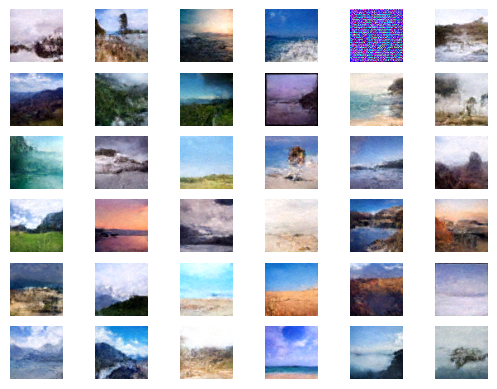

In [18]:
model.load_state_dict(torch.load("./models2/17_10_epoch30.pt"))
model.eval()

with torch.no_grad():
    imgs = diffusion.sample(model, 36).cpu()

    fig, ax = plt.subplots(6, 6)
    idx = 0
    for row in ax:
        for cell in row:
            cell.imshow(imgs[idx].permute(1, 2, 0))
            cell.axis("off")
            idx = idx + 1

    plt.show()